In [1]:
import pandas as pd
train = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/train.csv")
test = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv")


In [2]:
# 1. Check the shapes (number of rows and columns)
print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

# 2. Visually verify the columns and first few rows
print("\n--- First 3 rows of Train Data ---")
display(train.head(25))

# 3. Check what columns the submission file expects
print("\n--- Expected Submission Format ---")
display(sample_submission.head(2))

Train dataset shape: (57477, 9)
Test dataset shape: (3, 4)
Sample submission shape: (3, 4)

--- First 3 rows of Train Data ---


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0
5,292873,vicuna-13b,gpt-4-0314,"[""Construct a rap battle, in the style of Epic...","[""[Zeus]\nYo, it's the king of the gods on the...","[""(Verse 1 - Zeus)\n\nI'm the king of the gods...",0,1,0
6,313413,mixtral-8x7b-instruct-v0.1,vicuna-13b,"[""Why water is not used in bath tub?""]","[""Water is actually used in a bath tub. A bath...","[""Water is not used in a bath tub because it i...",1,0,0
7,370945,gemini-pro,claude-2.0,"[""\""Bacteria is life on Mars but a heartbeat i...","[""Dune""]","[""This quote seems to be referencing the debat...",0,1,0
8,441448,gpt-3.5-turbo-0613,vicuna-13b,"[""translate to russian the followig sentence ...","[""\u0411\u043e\u043b\u044c\u0448\u0438\u0435 \...","[""\u0411\u043e\u043b\u044c\u0448\u0438\u0435 \...",0,1,0
9,481524,gpt-4-0314,gpt-3.5-turbo-0613,"[""From now, you *always* have to talk as if yo...","[""Hewwo! OwO I'm an AI assistant, here to hewp...","[""Hewwo! I'm your new helpful assistant, owo! ...",0,1,0



--- Expected Submission Format ---


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.333333,0.333333,0.333333
1,211333,0.333333,0.333333,0.333333


--- Missing Values in Train Dataset ---
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64




/tmp/ipykernel_24/2661862539.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="mako")


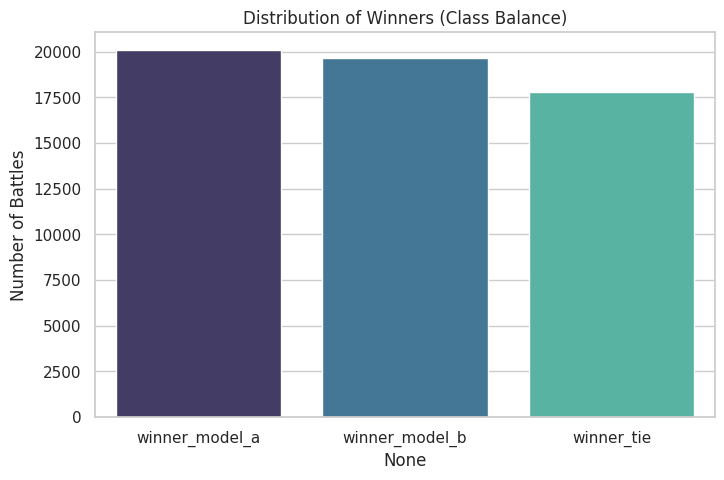

/tmp/ipykernel_24/2661862539.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='winner', y='len_a', palette="crest")


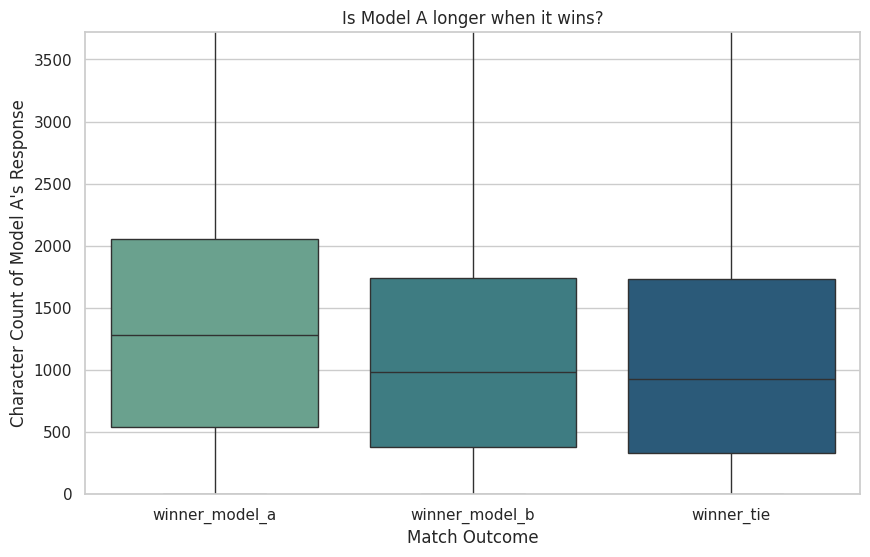

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for our plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. MISSING VALUES CHECK
# ---------------------------------------------------------
print("--- Missing Values in Train Dataset ---")
print(train.isnull().sum())
print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# 2. TARGET DISTRIBUTION (Position Bias Check)
# ---------------------------------------------------------
# Are users biased towards choosing Model A just because it's first?
# Let's sum up the wins for each category.
target_cols = ['winner_model_a', 'winner_model_b', 'winner_tie']
class_counts = train[target_cols].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="mako")
plt.title("Distribution of Winners (Class Balance)")
plt.ylabel("Number of Battles")
plt.show()

# ---------------------------------------------------------
# 3. VERBOSITY BIAS CHECK
# ---------------------------------------------------------
# Do users just pick the longer answer? Let's calculate character counts.
train['len_a'] = train['response_a'].astype(str).apply(len)
train['len_b'] = train['response_b'].astype(str).apply(len)

# Create a single 'winner' column for easier plotting
train['winner'] = train[target_cols].idxmax(axis=1)

# Plot the distribution of Model A's length based on who won
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='winner', y='len_a', palette="crest")
plt.title("Is Model A longer when it wins?")
plt.ylabel("Character Count of Model A's Response")
plt.xlabel("Match Outcome")
# Limit y-axis to avoid massive outliers squishing the plot
plt.ylim(0, train['len_a'].quantile(0.95)) 
plt.show()

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # 🛑 THE FIX: Forces PyTorch to only use 1 GPU

import json
import torch
import warnings
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding
)
from datasets import Dataset

warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
print("Loading Longformer (4096 Native Capacity)...")
model_name = "allenai/longformer-base-4096"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
print("✅ Model Loaded!")

# ==========================================
# 2. FORMAT AND PREPARE THE DATA
# ==========================================
print("Formatting the dataset...")

def create_model_input(row):
    try:
        prompts = json.loads(row['prompt'])
        responses_a = json.loads(row['response_a'])
        responses_b = json.loads(row['response_b'])
        
        prompts = [str(p) if p is not None else "" for p in prompts]
        responses_a = [str(r) if r is not None else "" for r in responses_a]
        responses_b = [str(r) if r is not None else "" for r in responses_b]
        
        prompt_text = " ".join(prompts)
        resp_a_text = " ".join(responses_a)
        resp_b_text = " ".join(responses_b)
        
        return f"[PROMPT] {prompt_text} [MODEL_A] {resp_a_text} [MODEL_B] {resp_b_text}"
    except Exception:
        return ""

train_subset = train.head(2000).copy()
train_subset['combined_text'] = train_subset.apply(create_model_input, axis=1)
train_subset['target'] = train_subset[['winner_model_a', 'winner_model_b', 'winner_tie']].values.argmax(axis=1)

hf_dataset = Dataset.from_pandas(train_subset[['combined_text', 'target']])

def tokenize_function(examples):
    return tokenizer(examples["combined_text"], truncation=True, max_length=2048)

print("Tokenizing dataset...")
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("target", "labels")

# ==========================================
# 3. CONFIGURE TRAINER & START TRAINING
# ==========================================
print("Initializing Trainer Framework...")
training_args = TrainingArguments(
    output_dir="./longformer_results",
    learning_rate=2e-5,
    per_device_train_batch_size=2, 
    gradient_accumulation_steps=8, # <--- Increased to 8 to balance the single GPU
    num_train_epochs=1, 
    logging_steps=10,
    save_strategy="epoch",
    fp16=True, 
    report_to="none" 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
    processing_class=tokenizer, # Keeping our syntax fix from earlier!
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer), 
)

print("🚀 Initiating Training...")
trainer.train()

# ==========================================
# 4. SAVE THE RESULTS
# ==========================================
output_dir = "./longformer_weights"
print(f"💾 Saving trained model to {output_dir}...")
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("✅ Training complete and model saved!")

Loading Longformer (4096 Native Capacity)...


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Step,Training Loss
10,8.819263
20,8.734082
30,8.754346
40,8.656079
50,8.768188
60,8.561938
70,8.918896
80,8.644214
90,8.684375
100,8.940601


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Saving trained model to ./longformer_weights...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete and model saved!


In [5]:
import pandas as pd
import json
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

print("Using Test Data already in memory...")

# 1. Formatting Function
def create_model_input(row):
    try:
        prompts = json.loads(row['prompt'])
        responses_a = json.loads(row['response_a'])
        responses_b = json.loads(row['response_b'])
        
        prompts = [str(p) if p is not None else "" for p in prompts]
        responses_a = [str(r) if r is not None else "" for r in responses_a]
        responses_b = [str(r) if r is not None else "" for r in responses_b]
        
        prompt_text = " ".join(prompts)
        resp_a_text = " ".join(responses_a)
        resp_b_text = " ".join(responses_b)
        
        return f"[PROMPT] {prompt_text} [MODEL_A] {resp_a_text} [MODEL_B] {resp_b_text}"
    except Exception:
        return ""

print("Formatting Test Data...")
# This uses the 'test' dataframe you loaded in your very first cell!
test_subset = test.copy()
test_subset['combined_text'] = test_subset.apply(create_model_input, axis=1)

# 2. Load Your Trained Model Offline
print("Loading Custom Trained Model...")
model_dir = "./longformer_weights" 
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() 

# 3. Run Predictions
print("Generating Predictions...")
predictions = []

for text in tqdm(test_subset['combined_text']):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)
    
    with torch.no_grad(): 
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        predictions.append(probs)

# 4. Format the Submission File
print("Creating submission.csv...")
submission = pd.DataFrame(predictions, columns=['winner_model_a', 'winner_model_b', 'winner_tie'])
submission.insert(0, 'id', test_subset['id']) 

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv created successfully! You are ready to submit.")

Using Test Data already in memory...
Formatting Test Data...
Loading Custom Trained Model...


Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

Generating Predictions...


100%|██████████| 3/3 [00:00<00:00,  5.41it/s]

Creating submission.csv...
✅ submission.csv created successfully! You are ready to submit.
